In [4]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [5]:
orders = pd.read_csv(
    "data/cleaned/orders_clean.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

items = pd.read_csv("data/cleaned/order_items_clean.csv")
products = pd.read_csv("data/cleaned/products_clean.csv")
customers = pd.read_csv("data/cleaned/customers_clean.csv")
payments = pd.read_csv("data/cleaned/payments_clean.csv")
reviews = pd.read_csv("data/cleaned/reviews_clean.csv")
sellers = pd.read_csv("data/cleaned/sellers_clean.csv")

In [6]:
master = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [7]:
master = master.merge(
    items,
    on="order_id",
    how="left"
)

In [8]:
master.shape

(113425, 18)

In [9]:
master = master.merge(
    products,
    on="product_id",
    how="left"
)

In [10]:
master = master.merge(
    sellers,
    on="seller_id",
    how="left"
)

In [11]:
payment_summary = payments.groupby("order_id").agg(
    payment_value=("payment_value", "sum"),
    payment_installments=("payment_installments", "max")
).reset_index()

In [12]:
master = master.merge(
    payment_summary,
    on="order_id",
    how="left"
)

In [13]:
review_summary = reviews.groupby("order_id").agg(
    review_score=("review_score", "mean")
).reset_index()

In [14]:
master = master.merge(
    review_summary,
    on="order_id",
    how="left"
)

In [15]:
master.shape

(113425, 33)

In [16]:
master["Revenue"] = master["price"]

In [17]:
master["Shipping_Cost"] = master["freight_value"]

In [18]:
master["Order_Month"] = (
    master["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [19]:
master["Order_Year"] = (
    master["order_purchase_timestamp"]
    .dt.year
)

In [20]:
master["Order_Day"] = (
    master["order_purchase_timestamp"]
    .dt.day_name()
)

In [21]:
master["Delivery_Days"] = (
    master["order_delivered_customer_date"]
    -
    master["order_purchase_timestamp"]
).dt.days

In [22]:
master["Delivery_Delay"] = (
    master["order_delivered_customer_date"]
    -
    master["order_estimated_delivery_date"]
).dt.days

In [23]:
cost_percentage = {
    "bed_bath_table":0.65,
    "health_beauty":0.60,
    "sports_leisure":0.55,
    "computers_accessories":0.75,
    "watches_gifts":0.70
}

In [24]:
master["Cost_Percentage"] = (
    master["product_category_name_english"]
    .map(cost_percentage)
    .fillna(0.65)
)

In [25]:
master["Product_Cost"] = (
    master["Revenue"]
    *
    master["Cost_Percentage"]
)

In [26]:
master["Profit"] = (
    master["Revenue"]
    -
    master["Product_Cost"]
    -
    master["Shipping_Cost"]
)

In [27]:
master["Profit_Margin"] = (
    master["Profit"]
    /
    master["Revenue"]
) * 100

In [28]:
master.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
product_category_name             775
product_name_lenght               775
product_description_lenght        775
product_photos_qty                775
product_weight_g                  775
product_length_cm                 775
product_height_cm                 775
product_width_cm                  775
product_cate

In [29]:
master[master["product_id"].isnull()].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,review_score,Revenue,Shipping_Cost,Order_Month,Order_Year,Order_Day,Delivery_Days,Delivery_Delay,Cost_Percentage,Product_Cost,Profit,Profit_Margin
306,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaT,NaT,2017-12-05,41fc647b8c6bd979b1b6364b60471b50,89288,sao bento do sul,SC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.00,5.0,1.0,NaN,NaN,2017-11,2017,Thursday,NaN,NaN,0.65,NaN,NaN,NaN
671,c272bcd21c287498b4883c7512019702,9582c5bbecc65eb568e2c1d839b5cba1,unavailable,2018-01-31 11:31:37,2018-01-31 14:23:50,NaT,NaT,2018-02-16,0e634b16e4c585acbd7b2e8276ce6677,11701,praia grande,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.68,1.0,3.0,NaN,NaN,2018-01,2018,Wednesday,NaN,NaN,0.65,NaN,NaN,NaN
791,37553832a3a89c9b2db59701c357ca67,7607cd563696c27ede287e515812d528,unavailable,2017-08-14 17:38:02,2017-08-17 00:15:18,NaT,NaT,2017-09-05,596ed6d7a35890b3fbac54ec01f69685,2318,sao paulo,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132.46,1.0,1.0,NaN,NaN,2017-08,2017,Monday,NaN,NaN,0.65,NaN,NaN,NaN
850,d57e15fb07fd180f06ab3926b39edcd2,470b93b3f1cde85550fc74cd3a476c78,unavailable,2018-01-08 19:39:03,2018-01-09 07:26:08,NaT,NaT,2018-02-06,2349bbb558908e0955e98d47dacb7adb,48607,paulo afonso,BA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134.38,1.0,1.0,NaN,NaN,2018-01,2018,Monday,NaN,NaN,0.65,NaN,NaN,NaN
1294,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12,4fa4365000c7090fcb8cad5713c6d3db,1151,sao paulo,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,1.0,1.0,NaN,NaN,2018-08,2018,Tuesday,NaN,NaN,0.65,NaN,NaN,NaN


In [30]:
master[master["product_id"].isna()]["order_status"].value_counts()

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

In [31]:
master_all_orders = master.copy()

In [32]:
sales_master = master[
    master["product_id"].notna()
].copy()

In [33]:
sales_master[
    [
        "product_id",
        "seller_id",
        "price",
        "freight_value",
        "Revenue",
        "Product_Cost",
        "Profit"
    ]
].isnull().sum()

product_id       0
seller_id        0
price            0
freight_value    0
Revenue          0
Product_Cost     0
Profit           0
dtype: int64

In [34]:
sales_master["order_status"].value_counts()

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

In [35]:
print("Total rows:", len(sales_master))
print("Unique orders:", sales_master["order_id"].nunique())
print("Unique products:", sales_master["product_id"].nunique())
print("Unique customers:", sales_master["customer_id"].nunique())

Total rows: 112650
Unique orders: 98666
Unique products: 32951
Unique customers: 98666


In [36]:
status_analysis = (
    sales_master["order_status"]
    .value_counts()
    .reset_index()
)

status_analysis.columns = ["Order_Status", "Count"]

status_analysis["Percentage"] = (
    status_analysis["Count"] /
    status_analysis["Count"].sum()
) * 100

status_analysis

,Order_Status,Count,Percentage
0,delivered,110197,97.822459
1,shipped,1185,1.051931
2,canceled,542,0.481136
3,invoiced,359,0.318686
4,processing,357,0.316911
5,unavailable,7,0.006214
6,approved,3,0.002663


In [37]:
delivered_sales = sales_master[
    sales_master["order_status"] == "delivered"
].copy()

In [38]:
print(delivered_sales.shape)
print(delivered_sales["order_id"].nunique())

(110197, 44)
96478


In [39]:
delivered_sales[
    [
        "Revenue",
        "Product_Cost",
        "Shipping_Cost",
        "Profit",
        "Profit_Margin"
    ]
].describe()

,Revenue,Product_Cost,Shipping_Cost,Profit,Profit_Margin
count,110197.000000,110197.000000,110197.000000,110197.000000,110197.000000
mean,119.980563,77.896978,19.948598,22.134988,3.154275
std,182.299446,119.267644,15.698136,59.156222,34.954702
min,0.850000,0.552500,0.000000,-237.910000,-2588.529412
25%,39.900000,25.935000,13.080000,-1.837500,-4.283668
50%,74.900000,48.685000,16.260000,8.215000,11.838340
75%,134.170000,87.000000,21.150000,26.625000,21.715271
max,6735.000000,4377.750000,409.680000,2162.940000,44.989990


In [40]:
print("Total Revenue:",
      delivered_sales["Revenue"].sum())

print("Total Product Cost:",
      delivered_sales["Product_Cost"].sum())

print("Total Shipping Cost:",
      delivered_sales["Shipping_Cost"].sum())

print("Total Profit:",
      delivered_sales["Profit"].sum())

Total Revenue: 13221498.110000001
Total Product Cost: 8584013.2405
Total Shipping Cost: 2198275.6399999997
Total Profit: 2439209.2295


In [41]:
total_revenue = delivered_sales["Revenue"].sum()
total_profit = delivered_sales["Profit"].sum()

overall_margin = (
    total_profit / total_revenue
) * 100

print("Overall Profit Margin:", overall_margin)

Overall Profit Margin: 18.448811240649942


In [42]:
loss_products = (
    delivered_sales
    .groupby(
        [
            "product_id",
            "product_category_name_english"
        ]
    )
    .agg(
        Revenue=("Revenue", "sum"),
        Product_Cost=("Product_Cost", "sum"),
        Shipping_Cost=("Shipping_Cost", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

In [43]:
loss_products = loss_products.sort_values(
    "Profit"
)

In [44]:
loss_products.head(10)

,product_id,product_category_name_english,Revenue,Product_Cost,Shipping_Cost,Profit
26436,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,45620.56,34215.4200,13336.75,-1931.6100
23656,bc3c6d2a621414f2e1df7a8a32a2828e,signaling_and_security,1050.00,682.5000,1794.96,-1427.4600
2734,154e7e31ebfa092203795c972e5804a6,health_beauty,6173.26,3703.9560,3650.94,-1181.6360
15824,7ce94ab189134e2d3c05f496d635419c,electronics,1433.25,931.6125,1641.05,-1139.4125
1340,0aabfb375647d9738ad0f7b4ea3653b1,consoles_games,3384.20,2199.7300,2022.85,-838.3800
3198,18b0e642cbae7251e60a64aa07dd9eb9,computers_accessories,1882.60,1411.9500,1217.19,-746.5400
24746,c4baedd846ed09b85f78a781b522f126,garden_tools,14869.03,9664.8695,5910.38,-706.2195
11465,5a6e53c3b4e8684b13388d6aa4afdf12,housewares,1190.27,773.6755,1111.20,-694.6055
1040,08574b074924071f4e201e151b152b4e,garden_tools,10434.30,6782.2950,4311.16,-659.1550
10772,54d9ac713e253fa1fae9c8003b011c2a,cool_stuff,3656.50,2376.7250,1892.05,-612.2750


In [45]:
monthly = (
    delivered_sales
    .groupby("Order_Month")
    .agg(
        Revenue=("Revenue", "sum"),
        Product_Cost=("Product_Cost", "sum"),
        Shipping_Cost=("Shipping_Cost", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

In [46]:
monthly["Profit_Margin"] = (
    monthly["Profit"] /
    monthly["Revenue"]
) * 100

In [47]:
monthly

,Order_Month,Revenue,Product_Cost,Shipping_Cost,Profit,Profit_Margin
0,2016-09,134.97,80.9820,8.49,45.4980,33.709713
1,2016-10,40325.11,26040.5995,6165.55,8118.9605,20.133759
2,2016-12,10.90,7.0850,8.72,-4.9050,-45.000000
3,2017-01,111798.36,71926.1380,15684.01,24188.2120,21.635570
4,2017-02,234223.40,151260.7445,37015.92,45946.7355,19.616629
5,2017-03,359198.85,233701.8400,55132.10,70364.9100,19.589403
6,2017-04,340669.68,221029.9195,50142.72,69497.0405,20.400125
7,2017-05,489338.25,318649.5995,77513.15,93175.5005,19.041123
8,2017-06,421923.37,274445.9085,68127.00,79350.4615,18.806842
9,2017-07,481604.52,313171.8255,84694.56,83738.1345,17.387323


In [48]:
monthly["Revenue_Growth_%"] = (
    monthly["Revenue"].pct_change()
) * 100

In [49]:
monthly["Profit_Growth_%"] = (
    monthly["Profit"].pct_change()
) * 100

In [50]:
monthly

,Order_Month,Revenue,Product_Cost,Shipping_Cost,Profit,Profit_Margin,Revenue_Growth_%,Profit_Growth_%
0,2016-09,134.97,80.9820,8.49,45.4980,33.709713,NaN,NaN
1,2016-10,40325.11,26040.5995,6165.55,8118.9605,20.133759,2.977709e+04,17744.653611
2,2016-12,10.90,7.0850,8.72,-4.9050,-45.000000,-9.997297e+01,-100.060414
3,2017-01,111798.36,71926.1380,15684.01,24188.2120,21.635570,1.025573e+06,-493233.781855
4,2017-02,234223.40,151260.7445,37015.92,45946.7355,19.616629,1.095052e+02,89.955072
5,2017-03,359198.85,233701.8400,55132.10,70364.9100,19.589403,5.335737e+01,53.144525
6,2017-04,340669.68,221029.9195,50142.72,69497.0405,20.400125,-5.158471e+00,-1.233384
7,2017-05,489338.25,318649.5995,77513.15,93175.5005,19.041123,4.364009e+01,34.071177
8,2017-06,421923.37,274445.9085,68127.00,79350.4615,18.806842,-1.377674e+01,-14.837633
9,2017-07,481604.52,313171.8255,84694.56,83738.1345,17.387323,1.414502e+01,5.529486


In [51]:
print("Rows:", len(sales_master))
print("Orders:", sales_master["order_id"].nunique())
print("Customers:", sales_master["customer_id"].nunique())

Rows: 112650
Orders: 98666
Customers: 98666


In [52]:
print("Revenue:", delivered_sales["Revenue"].sum())
print("Product Cost:", delivered_sales["Product_Cost"].sum())
print("Shipping:", delivered_sales["Shipping_Cost"].sum())
print("Profit:", delivered_sales["Profit"].sum())

print(
    "Margin:",
    delivered_sales["Profit"].sum()
    / delivered_sales["Revenue"].sum() * 100
)

Revenue: 13221498.110000001
Product Cost: 8584013.2405
Shipping: 2198275.6399999997
Profit: 2439209.2295
Margin: 18.448811240649942


In [53]:
monthly[
    [
        "Order_Month",
        "Revenue",
        "Profit",
        "Profit_Margin",
        "Revenue_Growth_%",
        "Profit_Growth_%"
    ]
]

,Order_Month,Revenue,Profit,Profit_Margin,Revenue_Growth_%,Profit_Growth_%
0,2016-09,134.97,45.4980,33.709713,NaN,NaN
1,2016-10,40325.11,8118.9605,20.133759,2.977709e+04,17744.653611
2,2016-12,10.90,-4.9050,-45.000000,-9.997297e+01,-100.060414
3,2017-01,111798.36,24188.2120,21.635570,1.025573e+06,-493233.781855
4,2017-02,234223.40,45946.7355,19.616629,1.095052e+02,89.955072
5,2017-03,359198.85,70364.9100,19.589403,5.335737e+01,53.144525
6,2017-04,340669.68,69497.0405,20.400125,-5.158471e+00,-1.233384
7,2017-05,489338.25,93175.5005,19.041123,4.364009e+01,34.071177
8,2017-06,421923.37,79350.4615,18.806842,-1.377674e+01,-14.837633
9,2017-07,481604.52,83738.1345,17.387323,1.414502e+01,5.529486


In [54]:
print(
    "Unique customers:",
    delivered_sales["customer_unique_id"].nunique()
)

Unique customers: 93358


In [55]:
customer_orders = (
    delivered_sales
    .groupby("customer_unique_id")["order_id"]
    .nunique()
)

customer_orders.describe()

count    93358.000000
mean         1.033420
std          0.209097
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         15.000000
Name: order_id, dtype: float64

In [56]:
customer_segment = customer_orders.apply(
    lambda x: "New Customer" if x == 1 else "Repeat Customer"
)

In [57]:
customer_segment = customer_segment.reset_index()

customer_segment.columns = [
    "customer_unique_id",
    "Customer_Type"
]

In [58]:
customer_segment["Customer_Type"].value_counts()

Customer_Type
New Customer       90557
Repeat Customer     2801
Name: count, dtype: int64

In [59]:
customer_segment["Customer_Type"].value_counts(
    normalize=True
) * 100

Customer_Type
New Customer       96.999722
Repeat Customer     3.000278
Name: proportion, dtype: float64

In [60]:
delivered_sales = delivered_sales.merge(
    customer_segment,
    on="customer_unique_id",
    how="left"
)

In [61]:
customer_analysis = (
    delivered_sales
    .groupby("Customer_Type")
    .agg(
        Revenue=("Revenue", "sum"),
        Profit=("Profit", "sum"),
        Orders=("order_id", "nunique"),
        Customers=("customer_unique_id", "nunique")
    )
    .reset_index()
)

In [62]:
customer_analysis

,Customer_Type,Revenue,Profit,Orders,Customers
0,New Customer,12493089.36,2.318864e+06,90557,90557
1,Repeat Customer,728408.75,1.203455e+05,5921,2801


In [63]:
category_analysis = (
    delivered_sales
    .groupby("product_category_name_english")
    .agg(
        Revenue=("Revenue", "sum"),
        Product_Cost=("Product_Cost", "sum"),
        Shipping_Cost=("Shipping_Cost", "sum"),
        Profit=("Profit", "sum"),
        Orders=("order_id", "nunique")
    )
    .reset_index()
)

In [64]:
category_analysis["Profit_Margin"] = (
    category_analysis["Profit"]
    / category_analysis["Revenue"]
) * 100

In [65]:
category_analysis.sort_values(
    "Revenue",
    ascending=False
).head(10)

,product_category_name_english,Revenue,Product_Cost,Shipping_Cost,Profit,Orders,Profit_Margin
44,health_beauty,1233131.72,739879.0320,178957.81,314294.8780,8647,25.487535
71,watches_gifts,1166176.98,816323.8860,98156.14,251696.9540,5495,21.583084
8,bed_bath_table,1023434.76,665232.5940,201774.50,156427.6660,9272,15.284576
66,sports_leisure,954852.55,525168.9025,163404.36,266279.2875,7530,27.886954
16,computers_accessories,888724.61,666543.4575,143999.16,78181.9925,6530,8.797100
40,furniture_decor,711927.69,462752.9985,168402.23,80772.4615,6307,11.345599
50,housewares,615628.69,400158.6485,142763.56,72706.4815,5743,11.810119
21,cool_stuff,610204.10,396632.6650,81476.79,132094.6450,3559,21.647617
6,auto,578966.65,376328.3225,90488.10,112150.2275,3810,19.370758
70,toys,471286.48,306336.2120,75774.58,89175.6880,3804,18.921758


In [66]:
category_analysis.sort_values(
    "Profit",
    ascending=False
).head(10)

,product_category_name_english,Revenue,Product_Cost,Shipping_Cost,Profit,Orders,Profit_Margin
44,health_beauty,1233131.72,739879.0320,178957.81,314294.8780,8647,25.487535
66,sports_leisure,954852.55,525168.9025,163404.36,266279.2875,7530,27.886954
71,watches_gifts,1166176.98,816323.8860,98156.14,251696.9540,5495,21.583084
8,bed_bath_table,1023434.76,665232.5940,201774.50,156427.6660,9272,15.284576
21,cool_stuff,610204.10,396632.6650,81476.79,132094.6450,3559,21.647617
6,auto,578966.65,376328.3225,90488.10,112150.2275,3810,19.370758
70,toys,471286.48,306336.2120,75774.58,89175.6880,3804,18.921758
60,perfumery,390144.65,253594.0225,53026.98,83523.6475,3086,21.408380
40,furniture_decor,711927.69,462752.9985,168402.23,80772.4615,6307,11.345599
16,computers_accessories,888724.61,666543.4575,143999.16,78181.9925,6530,8.797100


In [67]:
category_analysis.sort_values(
    "Profit"
).head(10)

,product_category_name_english,Revenue,Product_Cost,Shipping_Cost,Profit,Orders,Profit_Margin
47,home_comfort_2,760.27,494.1755,410.31,-144.2155,24,-18.968985
13,christmas_supplies,8737.84,5679.5960,3190.91,-132.6660,125,-1.518293
36,flowers,1110.04,721.5260,488.87,-100.3560,29,-9.040755
42,furniture_mattress_and_upholstery,4323.38,2810.1970,1581.37,-68.1870,37,-1.577169
24,diapers_and_hygiene,1500.79,975.5135,545.40,-20.1235,25,-1.340860
12,cds_dvds_musicals,730.00,474.5000,224.99,30.5100,12,4.179452
62,security_and_services,283.29,184.1385,41.22,57.9315,2,20.449539
30,fashion_childrens_clothes,519.95,337.9675,78.72,103.2625,7,19.860083
33,fashion_sport,2094.52,1361.4380,563.03,170.0520,26,8.118901
4,arts_and_craftmanship,1814.01,1179.1065,370.13,264.7735,23,14.596033


In [68]:
category_analysis.sort_values(
    "Profit_Margin"
).head(10)

,product_category_name_english,Revenue,Product_Cost,Shipping_Cost,Profit,Orders,Profit_Margin
47,home_comfort_2,760.27,494.1755,410.31,-144.2155,24,-18.968985
36,flowers,1110.04,721.5260,488.87,-100.3560,29,-9.040755
42,furniture_mattress_and_upholstery,4323.38,2810.1970,1581.37,-68.1870,37,-1.577169
13,christmas_supplies,8737.84,5679.5960,3190.91,-132.6660,125,-1.518293
24,diapers_and_hygiene,1500.79,975.5135,545.40,-20.1235,25,-1.340860
12,cds_dvds_musicals,730.00,474.5000,224.99,30.5100,12,4.179452
63,signaling_and_security,21315.05,13854.7825,6477.54,982.7275,138,4.610486
27,electronics,155043.93,100778.5545,45679.16,8586.2155,2517,5.537924
38,food_drink,14942.88,9712.8720,4394.89,835.1180,221,5.588735
26,dvds_blu_ray,4542.59,2952.6835,1227.25,362.6565,56,7.983474


In [70]:
shipping_analysis = (
    delivered_sales
    .groupby("product_category_name_english")
    .agg(
        Revenue=("Revenue", "sum"),
        Shipping_Cost=("Shipping_Cost", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

In [72]:
shipping_analysis["Shipping_%"] = (
    shipping_analysis["Shipping_Cost"]
    / shipping_analysis["Revenue"]
) * 100

In [73]:
shipping_analysis.sort_values(
    "Shipping_%",
    ascending=False
).head(10)

,product_category_name_english,Revenue,Shipping_Cost,Profit,Shipping_%
47,home_comfort_2,760.27,410.31,-144.2155,53.968985
36,flowers,1110.04,488.87,-100.3560,44.040755
42,furniture_mattress_and_upholstery,4323.38,1581.37,-68.1870,36.577169
13,christmas_supplies,8737.84,3190.91,-132.6660,36.518293
24,diapers_and_hygiene,1500.79,545.40,-20.1235,36.340860
12,cds_dvds_musicals,730.00,224.99,30.5100,30.820548
63,signaling_and_security,21315.05,6477.54,982.7275,30.389514
27,electronics,155043.93,45679.16,8586.2155,29.462076
38,food_drink,14942.88,4394.89,835.1180,29.411265
26,dvds_blu_ray,4542.59,1227.25,362.6565,27.016526


In [75]:
state_analysis = (
    delivered_sales
    .groupby("customer_state")
    .agg(
        Revenue=("Revenue", "sum"),
        Shipping_Cost=("Shipping_Cost", "sum"),
        Profit=("Profit", "sum"),
        Orders=("order_id", "nunique")
    )
    .reset_index()
)

In [76]:
state_analysis["Profit_Margin"] = (
    state_analysis["Profit"]
    / state_analysis["Revenue"]
) * 100

In [77]:
state_analysis["Shipping_%"] = (
    state_analysis["Shipping_Cost"]
    / state_analysis["Revenue"]
) * 100

In [78]:
state_analysis.sort_values(
    "Revenue",
    ascending=False
).head(10)

,customer_state,Revenue,Shipping_Cost,Profit,Orders,Profit_Margin,Shipping_%
25,SP,5067633.16,702069.99,1.076620e+06,40501,21.245028,13.854002
18,RJ,1759651.13,295750.44,3.187120e+05,12350,18.112229,16.807334
10,MG,1552481.83,266409.84,2.786810e+05,11354,17.950680,17.160255
22,RS,728897.47,132575.32,1.225853e+05,5345,16.817905,18.188473
17,PR,666063.51,115645.29,1.187158e+05,4923,17.823493,17.362502
23,SC,507012.13,88115.65,9.019218e+04,3546,17.788958,17.379397
4,BA,493584.14,97553.67,7.585438e+04,3256,15.368075,19.764345
6,DF,296498.41,49624.94,5.387342e+04,2080,18.169883,16.737000
8,GO,282836.70,51375.65,4.798174e+04,1957,16.964466,18.164421
7,ES,268643.45,49014.48,4.517515e+04,1995,16.816027,18.245180


In [79]:
state_analysis.sort_values(
    "Shipping_%",
    ascending=False
).head(10)

,customer_state,Revenue,Shipping_Cost,Profit,Orders,Profit_Margin,Shipping_%
21,RR,7057.47,1982.05,593.9300,41,8.415622,28.084427
9,MA,117009.38,30794.17,9934.4815,717,8.490329,26.317694
20,RO,45682.76,11283.24,4951.7315,243,10.839388,24.699121
2,AM,22155.84,5429.63,2330.6340,145,10.519276,24.506541
24,SE,56574.19,13714.94,6258.5220,335,11.062504,24.242397
16,PI,84721.00,20457.19,9373.3880,476,11.063831,24.146540
26,TO,48402.51,11604.86,5429.6335,274,11.217669,23.975740
0,AC,15930.97,3644.36,1975.2245,80,12.398646,22.875945
19,RN,82105.66,18609.12,10465.6980,474,12.746622,22.664844
15,PE,251889.49,57082.56,32094.5280,1593,12.741511,22.661747


In [80]:
state_analysis.sort_values(
    "Profit_Margin"
).head(10)

,customer_state,Revenue,Shipping_Cost,Profit,Orders,Profit_Margin,Shipping_%
21,RR,7057.47,1982.05,593.9300,41,8.415622,28.084427
9,MA,117009.38,30794.17,9934.4815,717,8.490329,26.317694
2,AM,22155.84,5429.63,2330.6340,145,10.519276,24.506541
20,RO,45682.76,11283.24,4951.7315,243,10.839388,24.699121
24,SE,56574.19,13714.94,6258.5220,335,11.062504,24.242397
16,PI,84721.00,20457.19,9373.3880,476,11.063831,24.146540
26,TO,48402.51,11604.86,5429.6335,274,11.217669,23.975740
0,AC,15930.97,3644.36,1975.2245,80,12.398646,22.875945
14,PB,112586.82,25251.73,13973.0780,517,12.410936,22.428673
15,PE,251889.49,57082.56,32094.5280,1593,12.741511,22.661747


In [81]:
monthly = (
    delivered_sales
    .groupby("Order_Month")
    .agg(
        Revenue=("Revenue", "sum"),
        Product_Cost=("Product_Cost", "sum"),
        Shipping_Cost=("Shipping_Cost", "sum"),
        Profit=("Profit", "sum"),
        Orders=("order_id", "nunique")
    )
    .reset_index()
)

In [82]:
monthly["Order_Month"] = pd.to_datetime(
    monthly["Order_Month"]
)

In [83]:
monthly = monthly.sort_values(
    "Order_Month"
)

In [84]:
monthly["Profit_Margin"] = (
    monthly["Profit"]
    / monthly["Revenue"]
) * 100

In [85]:
monthly["Shipping_%"] = (
    monthly["Shipping_Cost"]
    / monthly["Revenue"]
) * 100

In [86]:
monthly.tail(10)

,Order_Month,Revenue,Product_Cost,Shipping_Cost,Profit,Orders,Profit_Margin,Shipping_%
13,2017-11-01,987765.37,643597.3955,165598.83,178569.1445,7289,18.078093,16.764997
14,2017-12-01,726033.19,470235.6010,117045.10,138752.4890,5513,19.111039,16.121178
15,2018-01-01,924645.00,600558.1360,153242.46,170844.4040,7069,18.476756,16.573113
16,2018-02-01,826437.13,538550.6765,139731.28,148155.1735,6555,17.926974,16.907672
17,2018-03-01,953356.25,620545.3360,167241.99,165568.9240,7003,17.366952,17.542444
18,2018-04-01,973534.09,631833.1275,159344.84,182356.1225,6798,18.731355,16.367669
19,2018-05-01,977544.69,635787.7695,151229.83,190527.0905,6749,19.490371,15.470375
20,2018-06-01,856077.86,555053.7375,155900.43,145123.6925,6099,16.952160,18.211011
21,2018-07-01,867953.46,562456.5195,159853.82,145643.1205,6159,16.780061,18.417326
22,2018-08-01,838576.64,541512.8645,146915.00,150148.7755,6351,17.905194,17.519567


In [87]:
print("Unique customers:",
      delivered_sales["customer_unique_id"].nunique())

Unique customers: 93358


In [88]:
category_analysis.sort_values(
    "Revenue",
    ascending=False
).head(10)

,product_category_name_english,Revenue,Product_Cost,Shipping_Cost,Profit,Orders,Profit_Margin
44,health_beauty,1233131.72,739879.0320,178957.81,314294.8780,8647,25.487535
71,watches_gifts,1166176.98,816323.8860,98156.14,251696.9540,5495,21.583084
8,bed_bath_table,1023434.76,665232.5940,201774.50,156427.6660,9272,15.284576
66,sports_leisure,954852.55,525168.9025,163404.36,266279.2875,7530,27.886954
16,computers_accessories,888724.61,666543.4575,143999.16,78181.9925,6530,8.797100
40,furniture_decor,711927.69,462752.9985,168402.23,80772.4615,6307,11.345599
50,housewares,615628.69,400158.6485,142763.56,72706.4815,5743,11.810119
21,cool_stuff,610204.10,396632.6650,81476.79,132094.6450,3559,21.647617
6,auto,578966.65,376328.3225,90488.10,112150.2275,3810,19.370758
70,toys,471286.48,306336.2120,75774.58,89175.6880,3804,18.921758


In [89]:
category_analysis.sort_values(
    "Profit_Margin"
).head(10)


,product_category_name_english,Revenue,Product_Cost,Shipping_Cost,Profit,Orders,Profit_Margin
47,home_comfort_2,760.27,494.1755,410.31,-144.2155,24,-18.968985
36,flowers,1110.04,721.5260,488.87,-100.3560,29,-9.040755
42,furniture_mattress_and_upholstery,4323.38,2810.1970,1581.37,-68.1870,37,-1.577169
13,christmas_supplies,8737.84,5679.5960,3190.91,-132.6660,125,-1.518293
24,diapers_and_hygiene,1500.79,975.5135,545.40,-20.1235,25,-1.340860
12,cds_dvds_musicals,730.00,474.5000,224.99,30.5100,12,4.179452
63,signaling_and_security,21315.05,13854.7825,6477.54,982.7275,138,4.610486
27,electronics,155043.93,100778.5545,45679.16,8586.2155,2517,5.537924
38,food_drink,14942.88,9712.8720,4394.89,835.1180,221,5.588735
26,dvds_blu_ray,4542.59,2952.6835,1227.25,362.6565,56,7.983474


In [90]:
shipping_analysis.sort_values(
    "Shipping_%",
    ascending=False
).head(10)

,product_category_name_english,Revenue,Shipping_Cost,Profit,Shipping_%
47,home_comfort_2,760.27,410.31,-144.2155,53.968985
36,flowers,1110.04,488.87,-100.3560,44.040755
42,furniture_mattress_and_upholstery,4323.38,1581.37,-68.1870,36.577169
13,christmas_supplies,8737.84,3190.91,-132.6660,36.518293
24,diapers_and_hygiene,1500.79,545.40,-20.1235,36.340860
12,cds_dvds_musicals,730.00,224.99,30.5100,30.820548
63,signaling_and_security,21315.05,6477.54,982.7275,30.389514
27,electronics,155043.93,45679.16,8586.2155,29.462076
38,food_drink,14942.88,4394.89,835.1180,29.411265
26,dvds_blu_ray,4542.59,1227.25,362.6565,27.016526


In [91]:
state_analysis = (
    delivered_sales
    .groupby("customer_state")
    .agg(
        Revenue=("Revenue", "sum"),
        Shipping_Cost=("Shipping_Cost", "sum"),
        Product_Cost=("Product_Cost", "sum"),
        Profit=("Profit", "sum"),
        Orders=("order_id", "nunique"),
        Customers=("customer_unique_id", "nunique")
    )
    .reset_index()
)

In [92]:
state_analysis["Profit_Margin"] = (
    state_analysis["Profit"]
    / state_analysis["Revenue"]
) * 100

In [93]:
state_analysis["Shipping_%"] = (
    state_analysis["Shipping_Cost"]
    / state_analysis["Revenue"]
) * 100

In [94]:
state_analysis.sort_values(
    "Revenue",
    ascending=False
).head(10)

,customer_state,Revenue,Shipping_Cost,Product_Cost,Profit,Orders,Customers,Profit_Margin,Shipping_%
25,SP,5067633.16,702069.99,3.288943e+06,1.076620e+06,40501,39156,21.245028,13.854002
18,RJ,1759651.13,295750.44,1.145189e+06,3.187120e+05,12350,11917,18.112229,16.807334
10,MG,1552481.83,266409.84,1.007391e+06,2.786810e+05,11354,11001,17.950680,17.160255
22,RS,728897.47,132575.32,4.737369e+05,1.225853e+05,5345,5168,16.817905,18.188473
17,PR,666063.51,115645.29,4.317024e+05,1.187158e+05,4923,4769,17.823493,17.362502
23,SC,507012.13,88115.65,3.287043e+05,9.019218e+04,3546,3449,17.788958,17.379397
4,BA,493584.14,97553.67,3.201761e+05,7.585438e+04,3256,3158,15.368075,19.764345
6,DF,296498.41,49624.94,1.930001e+05,5.387342e+04,2080,2019,18.169883,16.737000
8,GO,282836.70,51375.65,1.834793e+05,4.798174e+04,1957,1895,16.964466,18.164421
7,ES,268643.45,49014.48,1.744538e+05,4.517515e+04,1995,1928,16.816027,18.245180


In [95]:
state_analysis.sort_values(
    "Shipping_%",
    ascending=False
).head(10)

,customer_state,Revenue,Shipping_Cost,Product_Cost,Profit,Orders,Customers,Profit_Margin,Shipping_%
21,RR,7057.47,1982.05,4481.4900,593.9300,41,40,8.415622,28.084427
9,MA,117009.38,30794.17,76280.7285,9934.4815,717,700,8.490329,26.317694
20,RO,45682.76,11283.24,29447.7885,4951.7315,243,231,10.839388,24.699121
2,AM,22155.84,5429.63,14395.5760,2330.6340,145,140,10.519276,24.506541
24,SE,56574.19,13714.94,36600.7280,6258.5220,335,329,11.062504,24.242397
16,PI,84721.00,20457.19,54890.4220,9373.3880,476,464,11.063831,24.146540
26,TO,48402.51,11604.86,31368.0165,5429.6335,274,267,11.217669,23.975740
0,AC,15930.97,3644.36,10311.3855,1975.2245,80,76,12.398646,22.875945
19,RN,82105.66,18609.12,53030.8420,10465.6980,474,464,12.746622,22.664844
15,PE,251889.49,57082.56,162712.4020,32094.5280,1593,1551,12.741511,22.661747


In [96]:
state_analysis.sort_values(
    "Profit_Margin"
).head(10)

,customer_state,Revenue,Shipping_Cost,Product_Cost,Profit,Orders,Customers,Profit_Margin,Shipping_%
21,RR,7057.47,1982.05,4481.4900,593.9300,41,40,8.415622,28.084427
9,MA,117009.38,30794.17,76280.7285,9934.4815,717,700,8.490329,26.317694
2,AM,22155.84,5429.63,14395.5760,2330.6340,145,140,10.519276,24.506541
20,RO,45682.76,11283.24,29447.7885,4951.7315,243,231,10.839388,24.699121
24,SE,56574.19,13714.94,36600.7280,6258.5220,335,329,11.062504,24.242397
16,PI,84721.00,20457.19,54890.4220,9373.3880,476,464,11.063831,24.146540
26,TO,48402.51,11604.86,31368.0165,5429.6335,274,267,11.217669,23.975740
0,AC,15930.97,3644.36,10311.3855,1975.2245,80,76,12.398646,22.875945
14,PB,112586.82,25251.73,73362.0120,13973.0780,517,504,12.410936,22.428673
15,PE,251889.49,57082.56,162712.4020,32094.5280,1593,1551,12.741511,22.661747


In [97]:
state_analysis[
    ["Shipping_%", "Profit_Margin"]
].corr()

,Shipping_%,Profit_Margin
Shipping_%,1.000000,-0.993926
Profit_Margin,-0.993926,1.000000


In [98]:
state_analysis.sort_values(
    "Revenue",
    ascending=False
).head(10)

,customer_state,Revenue,Shipping_Cost,Product_Cost,Profit,Orders,Customers,Profit_Margin,Shipping_%
25,SP,5067633.16,702069.99,3.288943e+06,1.076620e+06,40501,39156,21.245028,13.854002
18,RJ,1759651.13,295750.44,1.145189e+06,3.187120e+05,12350,11917,18.112229,16.807334
10,MG,1552481.83,266409.84,1.007391e+06,2.786810e+05,11354,11001,17.950680,17.160255
22,RS,728897.47,132575.32,4.737369e+05,1.225853e+05,5345,5168,16.817905,18.188473
17,PR,666063.51,115645.29,4.317024e+05,1.187158e+05,4923,4769,17.823493,17.362502
23,SC,507012.13,88115.65,3.287043e+05,9.019218e+04,3546,3449,17.788958,17.379397
4,BA,493584.14,97553.67,3.201761e+05,7.585438e+04,3256,3158,15.368075,19.764345
6,DF,296498.41,49624.94,1.930001e+05,5.387342e+04,2080,2019,18.169883,16.737000
8,GO,282836.70,51375.65,1.834793e+05,4.798174e+04,1957,1895,16.964466,18.164421
7,ES,268643.45,49014.48,1.744538e+05,4.517515e+04,1995,1928,16.816027,18.245180


In [99]:
state_analysis.sort_values(
    "Shipping_%",
    ascending=False
).head(10)

,customer_state,Revenue,Shipping_Cost,Product_Cost,Profit,Orders,Customers,Profit_Margin,Shipping_%
21,RR,7057.47,1982.05,4481.4900,593.9300,41,40,8.415622,28.084427
9,MA,117009.38,30794.17,76280.7285,9934.4815,717,700,8.490329,26.317694
20,RO,45682.76,11283.24,29447.7885,4951.7315,243,231,10.839388,24.699121
2,AM,22155.84,5429.63,14395.5760,2330.6340,145,140,10.519276,24.506541
24,SE,56574.19,13714.94,36600.7280,6258.5220,335,329,11.062504,24.242397
16,PI,84721.00,20457.19,54890.4220,9373.3880,476,464,11.063831,24.146540
26,TO,48402.51,11604.86,31368.0165,5429.6335,274,267,11.217669,23.975740
0,AC,15930.97,3644.36,10311.3855,1975.2245,80,76,12.398646,22.875945
19,RN,82105.66,18609.12,53030.8420,10465.6980,474,464,12.746622,22.664844
15,PE,251889.49,57082.56,162712.4020,32094.5280,1593,1551,12.741511,22.661747


In [100]:
state_analysis.sort_values(
    "Profit_Margin"
).head(10)

,customer_state,Revenue,Shipping_Cost,Product_Cost,Profit,Orders,Customers,Profit_Margin,Shipping_%
21,RR,7057.47,1982.05,4481.4900,593.9300,41,40,8.415622,28.084427
9,MA,117009.38,30794.17,76280.7285,9934.4815,717,700,8.490329,26.317694
2,AM,22155.84,5429.63,14395.5760,2330.6340,145,140,10.519276,24.506541
20,RO,45682.76,11283.24,29447.7885,4951.7315,243,231,10.839388,24.699121
24,SE,56574.19,13714.94,36600.7280,6258.5220,335,329,11.062504,24.242397
16,PI,84721.00,20457.19,54890.4220,9373.3880,476,464,11.063831,24.146540
26,TO,48402.51,11604.86,31368.0165,5429.6335,274,267,11.217669,23.975740
0,AC,15930.97,3644.36,10311.3855,1975.2245,80,76,12.398646,22.875945
14,PB,112586.82,25251.73,73362.0120,13973.0780,517,504,12.410936,22.428673
15,PE,251889.49,57082.56,162712.4020,32094.5280,1593,1551,12.741511,22.661747


In [101]:
state_analysis[
    ["Shipping_%", "Profit_Margin"]
].corr()

,Shipping_%,Profit_Margin
Shipping_%,1.000000,-0.993926
Profit_Margin,-0.993926,1.000000


Calculate orders per customer


In [102]:
customer_orders = (
    delivered_sales
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index()
)

customer_orders.columns = [
    "customer_unique_id",
    "Order_Count"
]

In [104]:
customer_orders["Customer_Type"] = np.where(
    customer_orders["Order_Count"] == 1,
    "New Customer",
    "Repeat Customer"
)

In [105]:
customer_orders["Customer_Type"].value_counts()

Customer_Type
New Customer       90557
Repeat Customer     2801
Name: count, dtype: int64

In [106]:
delivered_sales = delivered_sales.merge(
    customer_orders[
        ["customer_unique_id", "Customer_Type"]
    ],
    on="customer_unique_id",
    how="left"
)

In [108]:
customer_orders = (
    delivered_sales
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index()
)

customer_orders.columns = [
    "customer_unique_id",
    "Order_Count"
]

customer_orders.head()

,customer_unique_id,Order_Count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [110]:
customer_orders["Customer_Type"] = np.where(
    customer_orders["Order_Count"] == 1,
    "New Customer",
    "Repeat Customer"
)
customer_orders["Customer_Type"].value_counts()

Customer_Type
New Customer       90557
Repeat Customer     2801
Name: count, dtype: int64

In [111]:
delivered_sales = delivered_sales.merge(
    customer_orders[
        ["customer_unique_id", "Customer_Type"]
    ],
    on="customer_unique_id",
    how="left"
)

In [112]:
customer_analysis = (
    delivered_sales
    .groupby("Customer_Type")
    .agg(
        Revenue=("Revenue", "sum"),
        Product_Cost=("Product_Cost", "sum"),
        Shipping_Cost=("Shipping_Cost", "sum"),
        Profit=("Profit", "sum"),
        Orders=("order_id", "nunique"),
        Customers=("customer_unique_id", "nunique")
    )
    .reset_index()
)

In [113]:
customer_analysis["Profit_Margin"] = (
    customer_analysis["Profit"]
    / customer_analysis["Revenue"]
) * 100

In [114]:
customer_analysis["Avg_Order_Value"] = (
    customer_analysis["Revenue"]
    / customer_analysis["Orders"]
)

In [115]:
customer_analysis

,Customer_Type,Revenue,Product_Cost,Shipping_Cost,Profit,Orders,Customers,Profit_Margin,Avg_Order_Value
0,New Customer,12493089.36,8.111729e+06,2062496.93,2.318864e+06,90557,90557,18.561172,137.958295
1,Repeat Customer,728408.75,4.722846e+05,135778.71,1.203455e+05,5921,2801,16.521695,123.021238


In [ ]:
sales_master.to_csv(
    "data/cleaned/master_sales.csv",
    index=False
)


In [120]:
master_all_orders = pd.read_csv(
    "data/cleaned/master_sales.csv"
)

In [121]:
master_all_orders.shape

(112650, 44)

In [122]:
master_all_orders["order_status"].value_counts()

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

In [123]:
total_orders = master_all_orders["order_id"].nunique()

cancelled_orders = master_all_orders[
    master_all_orders["order_status"] == "canceled"
]["order_id"].nunique()

cancellation_rate = (
    cancelled_orders / total_orders
) * 100

print("Total Orders:", total_orders)
print("Cancelled Orders:", cancelled_orders)
print("Cancellation Rate:", cancellation_rate)

Total Orders: 98666
Cancelled Orders: 461
Cancellation Rate: 0.46723288670869395


In [124]:
master_all_orders["Order_Month"] = pd.to_datetime(
    master_all_orders["order_purchase_timestamp"]
).dt.to_period("M").astype(str)

In [125]:
monthly_cancellations = (
    master_all_orders
    .groupby("Order_Month")
    .agg(
        Total_Orders=("order_id", "nunique")
    )
    .reset_index()
)

In [126]:
cancelled_monthly = (
    master_all_orders[
        master_all_orders["order_status"] == "canceled"
    ]
    .groupby("Order_Month")["order_id"]
    .nunique()
    .reset_index(name="Cancelled_Orders")
)

In [127]:
monthly_cancellations = monthly_cancellations.merge(
    cancelled_monthly,
    on="Order_Month",
    how="left"
)

In [129]:
monthly_cancellations["Cancelled_Orders"] = (
    monthly_cancellations["Cancelled_Orders"]
    .fillna(0)
)

In [130]:
monthly_cancellations["Cancellation_Rate_%"] = (
    monthly_cancellations["Cancelled_Orders"]
    / monthly_cancellations["Total_Orders"]
) * 100

In [131]:
monthly_cancellations.tail(15)

,Order_Month,Total_Orders,Cancelled_Orders,Cancellation_Rate_%
9,2017-07,3969,23.0,0.579491
10,2017-08,4293,21.0,0.489168
11,2017-09,4243,16.0,0.377092
12,2017-10,4568,21.0,0.459720
13,2017-11,7451,30.0,0.402631
14,2017-12,5624,6.0,0.106686
15,2018-01,7220,33.0,0.457064
16,2018-02,6694,70.0,1.045713
17,2018-03,7188,20.0,0.278242
18,2018-04,6934,15.0,0.216325


In [132]:
rca_summary = pd.DataFrame({
    "Factor": [
        "Shipping Cost",
        "Product Mix",
        "Regional Logistics",
        "Customer Type",
        "Cancellations"
    ],
    "Impact": [
        "High",
        "High",
        "High",
        "To Evaluate",
        "To Evaluate"
    ],
    "Evidence": [
        "High shipping burden in several categories",
        "Large differences in category margins",
        "Remote states show higher shipping %",
        "New vs repeat customer profitability",
        "Cancellation rate analysis"
    ]
})

rca_summary

,Factor,Impact,Evidence
0,Shipping Cost,High,High shipping burden in several categories
1,Product Mix,High,Large differences in category margins
2,Regional Logistics,High,Remote states show higher shipping %
3,Customer Type,To Evaluate,New vs repeat customer profitability
4,Cancellations,To Evaluate,Cancellation rate analysis


In [133]:
monthly_analysis = (
    delivered_sales
    .groupby("Order_Month")
    .agg(
        Revenue=("Revenue", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

monthly_analysis["Profit_Margin"] = (
    monthly_analysis["Profit"]
    / monthly_analysis["Revenue"]
) * 100

monthly_analysis

,Order_Month,Revenue,Profit,Profit_Margin
0,2016-09,134.97,45.4980,33.709713
1,2016-10,40325.11,8118.9605,20.133759
2,2016-12,10.90,-4.9050,-45.000000
3,2017-01,111798.36,24188.2120,21.635570
4,2017-02,234223.40,45946.7355,19.616629
5,2017-03,359198.85,70364.9100,19.589403
6,2017-04,340669.68,69497.0405,20.400125
7,2017-05,489338.25,93175.5005,19.041123
8,2017-06,421923.37,79350.4615,18.806842
9,2017-07,481604.52,83738.1345,17.387323


In [147]:
pip install matplotlib seaborn

  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Matplotlib is building the font cache; this may take a moment.


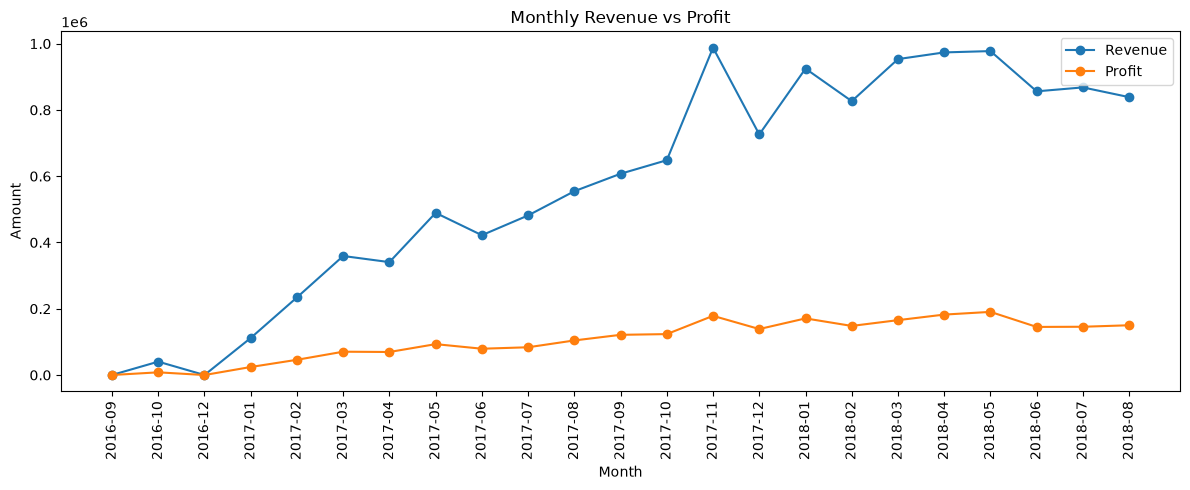

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    monthly_analysis["Order_Month"],
    monthly_analysis["Revenue"],
    marker="o",
    label="Revenue"
)

plt.plot(
    monthly_analysis["Order_Month"],
    monthly_analysis["Profit"],
    marker="o",
    label="Profit"
)

plt.xticks(rotation=90)
plt.title("Monthly Revenue vs Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.tight_layout()
plt.show()

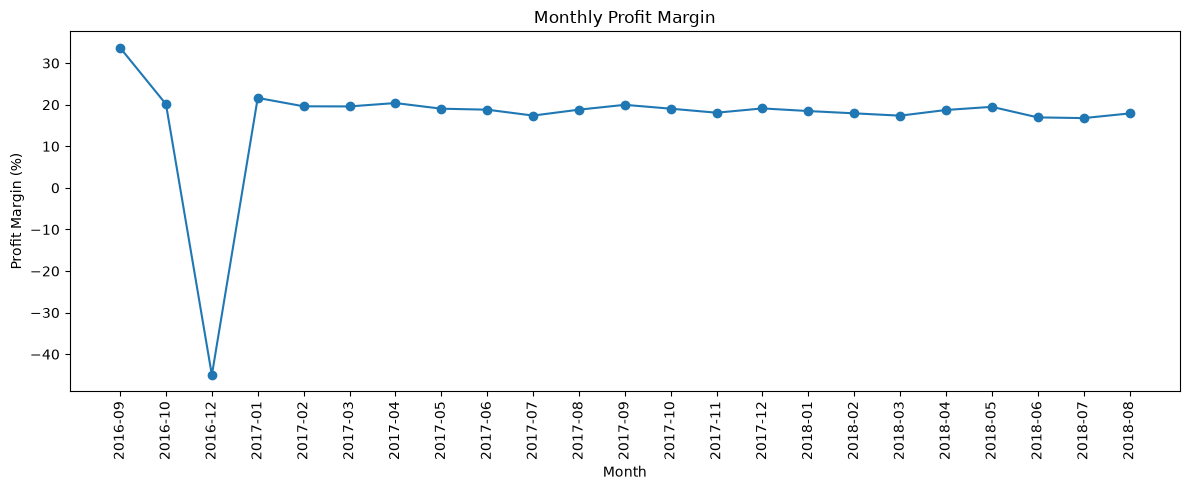

In [149]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_analysis["Order_Month"],
    monthly_analysis["Profit_Margin"],
    marker="o"
)

plt.xticks(rotation=90)
plt.title("Monthly Profit Margin")
plt.xlabel("Month")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

In [150]:
high_revenue_low_margin = category_analysis[
    (category_analysis["Revenue"] >
     category_analysis["Revenue"].median()) &
    (category_analysis["Profit_Margin"] <
     category_analysis["Profit_Margin"].median())
]

high_revenue_low_margin.sort_values(
    "Revenue",
    ascending=False
)

,product_category_name_english,Revenue,Product_Cost,Shipping_Cost,Profit,Orders,Profit_Margin,Shipping_%
8,bed_bath_table,1023434.76,665232.5940,201774.50,156427.6660,9272,15.284576,19.715424
16,computers_accessories,888724.61,666543.4575,143999.16,78181.9925,6530,8.797100,16.202900
40,furniture_decor,711927.69,462752.9985,168402.23,80772.4615,6307,11.345599,23.654401
50,housewares,615628.69,400158.6485,142763.56,72706.4815,5743,11.810119,23.189881
43,garden_tools,470495.28,305821.9320,96650.40,68022.9480,3448,14.457732,20.542268
69,telephony,309860.23,201409.1495,69342.39,39108.6905,4093,12.621397,22.378603
58,office_furniture,268154.31,174300.3015,67057.05,26796.9585,1254,9.993111,25.006889
67,stationery,223788.69,145462.6485,45786.36,32539.6815,2264,14.540360,20.459640
27,electronics,155043.93,100778.5545,45679.16,8586.2155,2517,5.537924,29.462076
29,fashion_bags_accessories,149329.39,97064.1035,30558.90,21706.3865,1820,14.535911,20.464089


In [152]:
category_analysis["Shipping_%"] = (
    category_analysis["Shipping_Cost"]
    / category_analysis["Revenue"]
) * 100

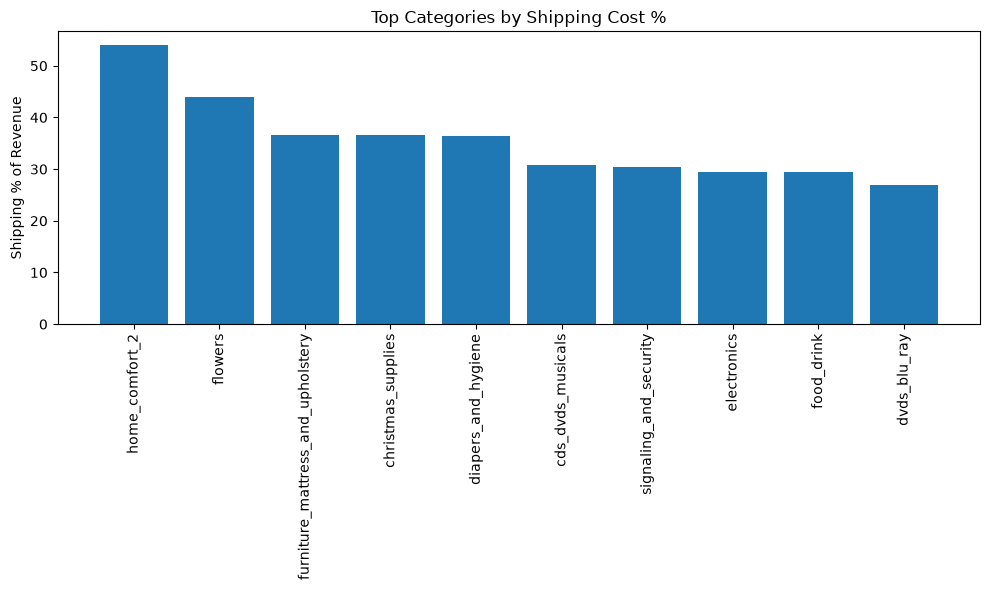

In [153]:
top_shipping = (
    category_analysis
    .sort_values("Shipping_%", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(
    top_shipping["product_category_name_english"],
    top_shipping["Shipping_%"]
)

plt.xticks(rotation=90)
plt.title("Top Categories by Shipping Cost %")
plt.ylabel("Shipping % of Revenue")
plt.tight_layout()
plt.show()

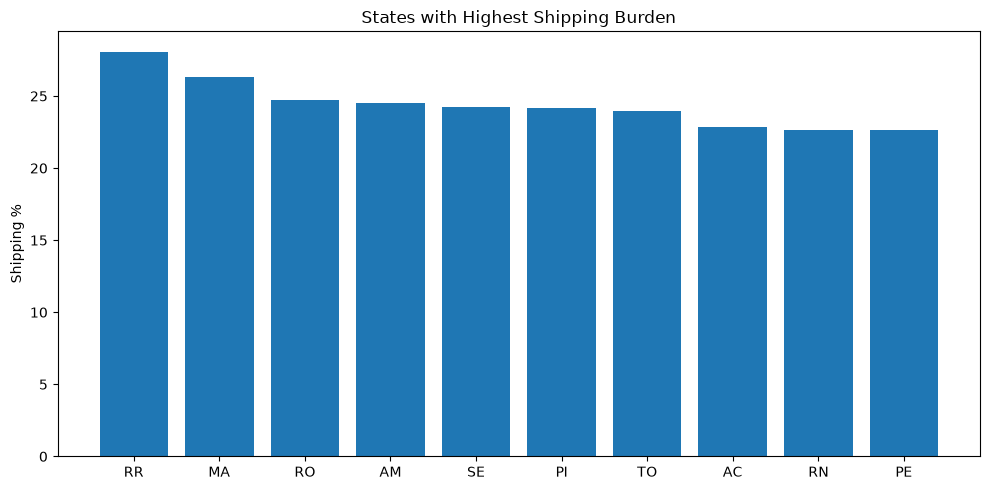

In [154]:
top_states = (
    state_analysis
    .sort_values("Shipping_%", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    top_states["customer_state"],
    top_states["Shipping_%"]
)

plt.title("States with Highest Shipping Burden")
plt.ylabel("Shipping %")
plt.tight_layout()
plt.show()

In [155]:
customer_analysis

,Customer_Type,Revenue,Product_Cost,Shipping_Cost,Profit,Orders,Customers,Profit_Margin,Avg_Order_Value
0,New Customer,12493089.36,8.111729e+06,2062496.93,2.318864e+06,90557,90557,18.561172,137.958295
1,Repeat Customer,728408.75,4.722846e+05,135778.71,1.203455e+05,5921,2801,16.521695,123.021238


In [156]:
master_sales = pd.read_csv(
    "data/cleaned/master_sales.csv"
)

In [157]:
master_sales["order_status"].value_counts()

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

In [158]:
total_orders = master_sales["order_id"].nunique()

cancelled_orders = master_sales[
    master_sales["order_status"] == "canceled"
]["order_id"].nunique()

print("Cancellation Rate:",
      round(cancelled_orders/total_orders*100,2), "%")

Cancellation Rate: 0.47 %


In [159]:
rca = pd.DataFrame({
    "Root Cause":[
        "High Shipping Cost",
        "Low Margin Categories",
        "Regional Logistics",
        "Customer Mix",
        "Order Cancellations"
    ],
    "Evidence":[
        "Shipping % exceeds 30–50% in several categories",
        "Some categories have negative estimated profit",
        "Remote states show higher shipping burden",
        "Based on customer analysis",
        "Based on cancellation rate"
    ],
    "Business Impact":[
        "High",
        "High",
        "Medium",
        "Medium",
        "Low/Medium"
    ]
})

rca

,Root Cause,Evidence,Business Impact
0,High Shipping Cost,Shipping % exceeds 30–50% in several categories,High
1,Low Margin Categories,Some categories have negative estimated profit,High
2,Regional Logistics,Remote states show higher shipping burden,Medium
3,Customer Mix,Based on customer analysis,Medium
4,Order Cancellations,Based on cancellation rate,Low/Medium
